# How to maintain a diverse repertoire? 

In [345]:
import numpy as np
import pyrepseq as prs
import matplotlib.pyplot as plt

import repertoire_simulator.lib as lib


plt.style.use("../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../data/"

## The REM transition to unevenness

In [417]:
Ds = np.logspace(-1, 1, 10)
results_for_strength = {}
cs_final_for_strength = {}
for D in Ds:
    records = np.load(DATA_PATH + f"how_to_maintain_diversity/rem_transition/noise_strength_{D}.npz", allow_pickle=True)
    t = records['t']
    c_t = records['c']
    Seff = np.zeros(len(t))
    
    cs_final_for_strength[D] = c_t[50]
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
    
    results_for_strength[D] = {'t':t, 'Seff':Seff}

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

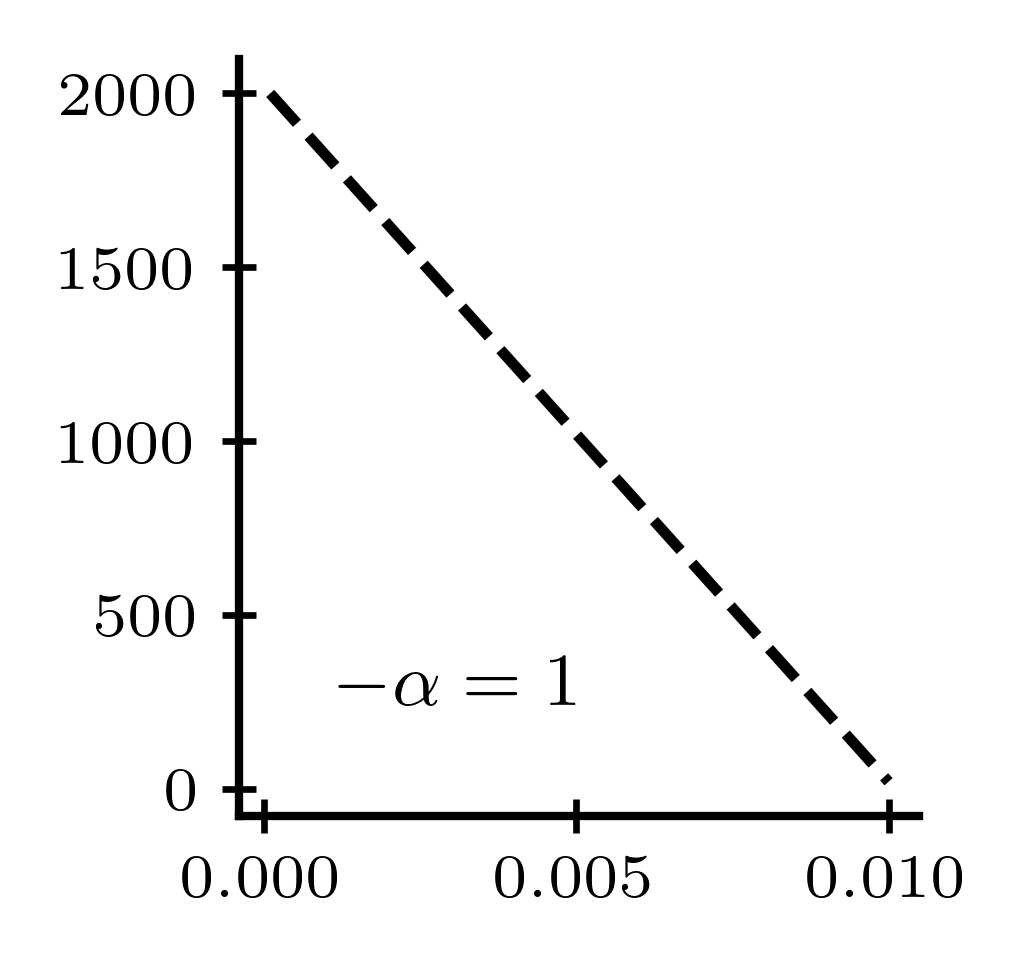

In [418]:
fig, ax = plt.subplots(figsize=(1.6, 1.5), layout='constrained')
lib.plot_referencescaling(ax=ax, x=[1e-4, 1e-2], factor=2e-1, exponent=-1, linestyle='--')
for D in Ds:
    c = cs_final_for_strength[D]
    prs.plotting.rankfrequency(c[c >= 1], ax=ax, normalize_x=True, alpha=0.7)
ax.set_xlim([1e-6, 1e0]);

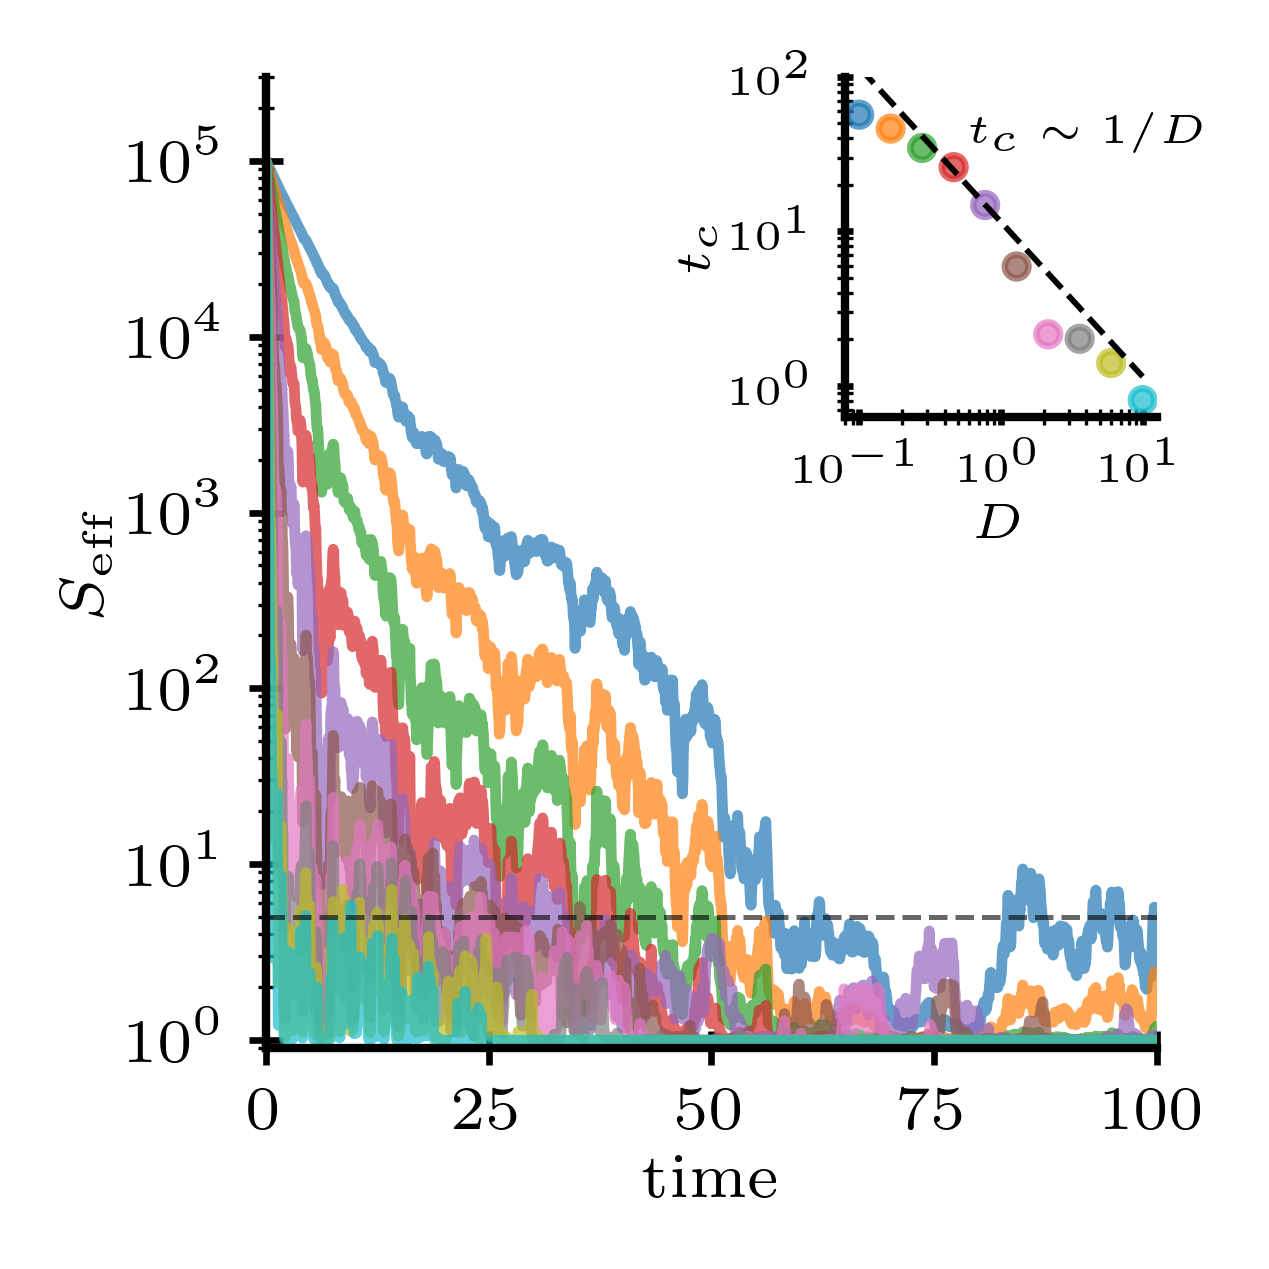

In [ ]:
fig, ax = plt.subplots(figsize=(2, 2), layout='constrained')

Ds_arr = np.asarray(Ds)
t_cs = np.full(len(Ds_arr), np.nan)
colors = []

for i, D in enumerate(Ds_arr):
    t = results_for_strength[D]['t']
    Seff = results_for_strength[D]['Seff']

    line, = ax.plot(t, Seff, alpha=0.7)
    colors.append(line.get_color())

    below = np.where(Seff <= 5)[0]
    if len(below) > 0:
        t_cs[i] = t[below[0]]

ax.axhline(5, color='k', lw=0.6, ls='--', alpha=0.6)

ax.set_yscale('log')
ax.set_xlim(0, 100)
ax.set_ylim(0.9, 3e5)
ax.set_xlabel(r'time')
ax.set_ylabel(r'$S_{\mathrm{eff}}$')

inset = ax.inset_axes([0.65, 0.65, 0.35, 0.35])

mask = np.isfinite(t_cs)

inset.set_xscale('log')
inset.set_yscale('log')
inset.plot(Ds_arr, np.log(1e5) / Ds_arr , linestyle='--', c='black', lw=0.7)
inset.text(0.4, 0.9, r'$t_c \sim 1/D$', transform=inset.transAxes, fontsize=5, ha='left',va='top')

inset.scatter(Ds_arr[mask],t_cs[mask], s=8, c=np.asarray(colors)[mask], alpha=0.7)

inset.set_ylim([None, 100])

inset.set_xlabel(r'$D$', fontsize=6)
inset.set_ylabel(r'$t_c$', fontsize=6)
inset.tick_params(axis='both', labelsize=5, length=2)

## Diversity sustained by an influx of new clones

In [484]:
ratios = np.logspace(3.5, 5.5, 10)
results_for_ratio = {}
cs_final_for_ratio = {}
cmaxes_for_ratio = {}
for ratio in ratios:
    records = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/ratio_{ratio}.npz", allow_pickle=True)
    t = records['t']
    c_t = records['c']
    Seff = np.zeros(len(t))
    T = np.zeros(len(t))
    
    cmaxes_for_ratio[ratio] = max(np.max(np.asarray(x)) for x in c_t)
    cs_final_for_ratio[ratio] = c_t[50]
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        T[i] = np.mean(c_t[i].sum(axis=0))
        
    
    results_for_ratio[ratio] = {'t':t, 'Seff':Seff, 'T':T}

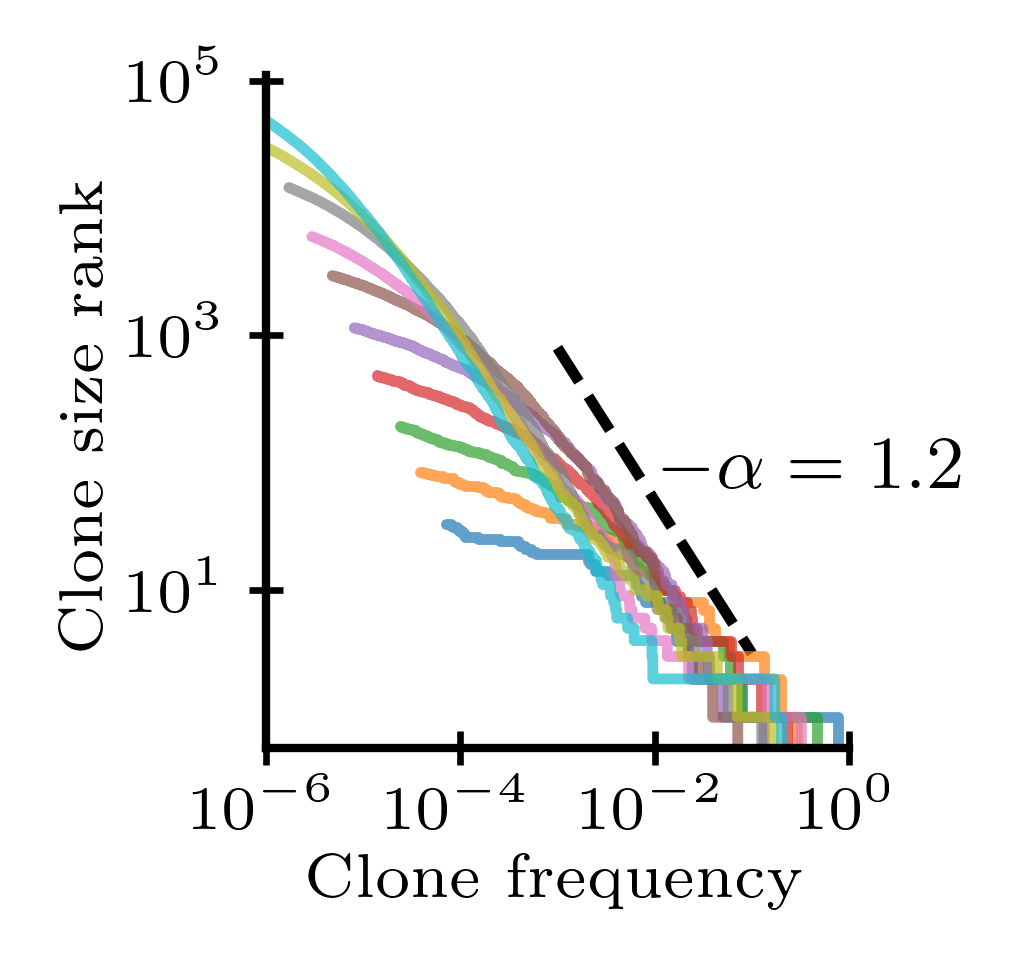

In [485]:
fig, ax = plt.subplots(figsize=(1.6, 1.5), layout='constrained')
lib.plot_referencescaling(ax=ax, x=[1e-3, 1e-1], factor=2e-1, exponent=-1.2, linestyle='--')
for ratio in ratios:
    c = cs_final_for_ratio[ratio]
    prs.plotting.rankfrequency(c[c >= 1], ax=ax, normalize_x=True, alpha=0.7)
ax.set_xlim([1e-6, 1e0]);

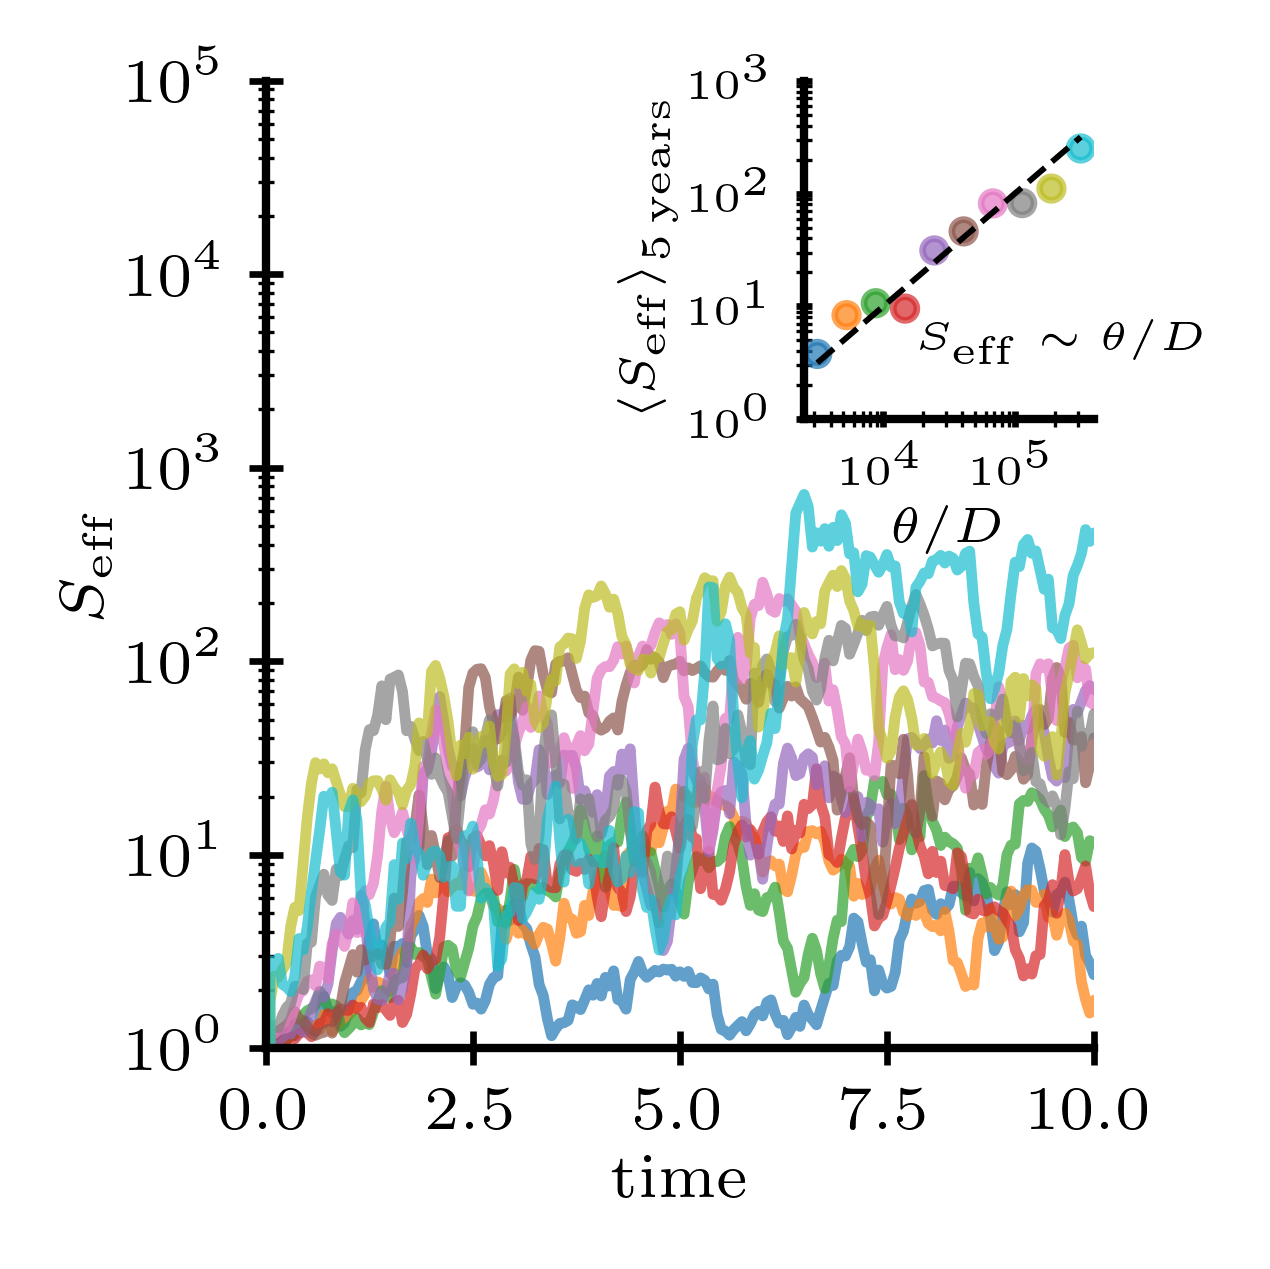

In [483]:
fig, ax = plt.subplots(figsize=(2, 2), layout='constrained')

alpha = 1.2
average_diversities = []
colors = []
for ratio in ratios:
    t =  results_for_ratio[ratio]['t']
    Seff =  results_for_ratio[ratio]['Seff']
    line, = ax.plot(t, Seff, alpha=0.7)
    colors.append(line.get_color())    
    average_diversities.append(np.mean(Seff[int(len(Seff) / 10 * (10 - 5)):]))

ax.set_yscale('log')
ax.set_xlim(0, 10)
ax.set_ylim(1, 1e5)
ax.set_xlabel(r'time')
ax.set_ylabel(r'$S_{\mathrm{eff}}$')

inset = ax.inset_axes([0.65, 0.65, 0.35, 0.35])
inset.set_xscale('log')
inset.set_yscale('log')

inset.plot(ratios, 1e-3 * ratios , linestyle='--', c='black', lw=0.7)
inset.scatter(ratios, average_diversities, s=8, c=np.asarray(colors), alpha=0.7)
inset.text(0.4, 0.3, r'$S_{\mathrm{eff}} \sim \theta/D$', transform=inset.transAxes, fontsize=5, ha='left',va='top')
inset.set_ylim([1, 1e3])

inset.set_xlabel(r'$\theta / D$', fontsize=6)
inset.set_ylabel(r'$\left<S_{\mathrm{eff}}\right>_{5 \, \mathrm{years}}$', fontsize=6)
inset.tick_params(axis='both', labelsize=5, length=2)

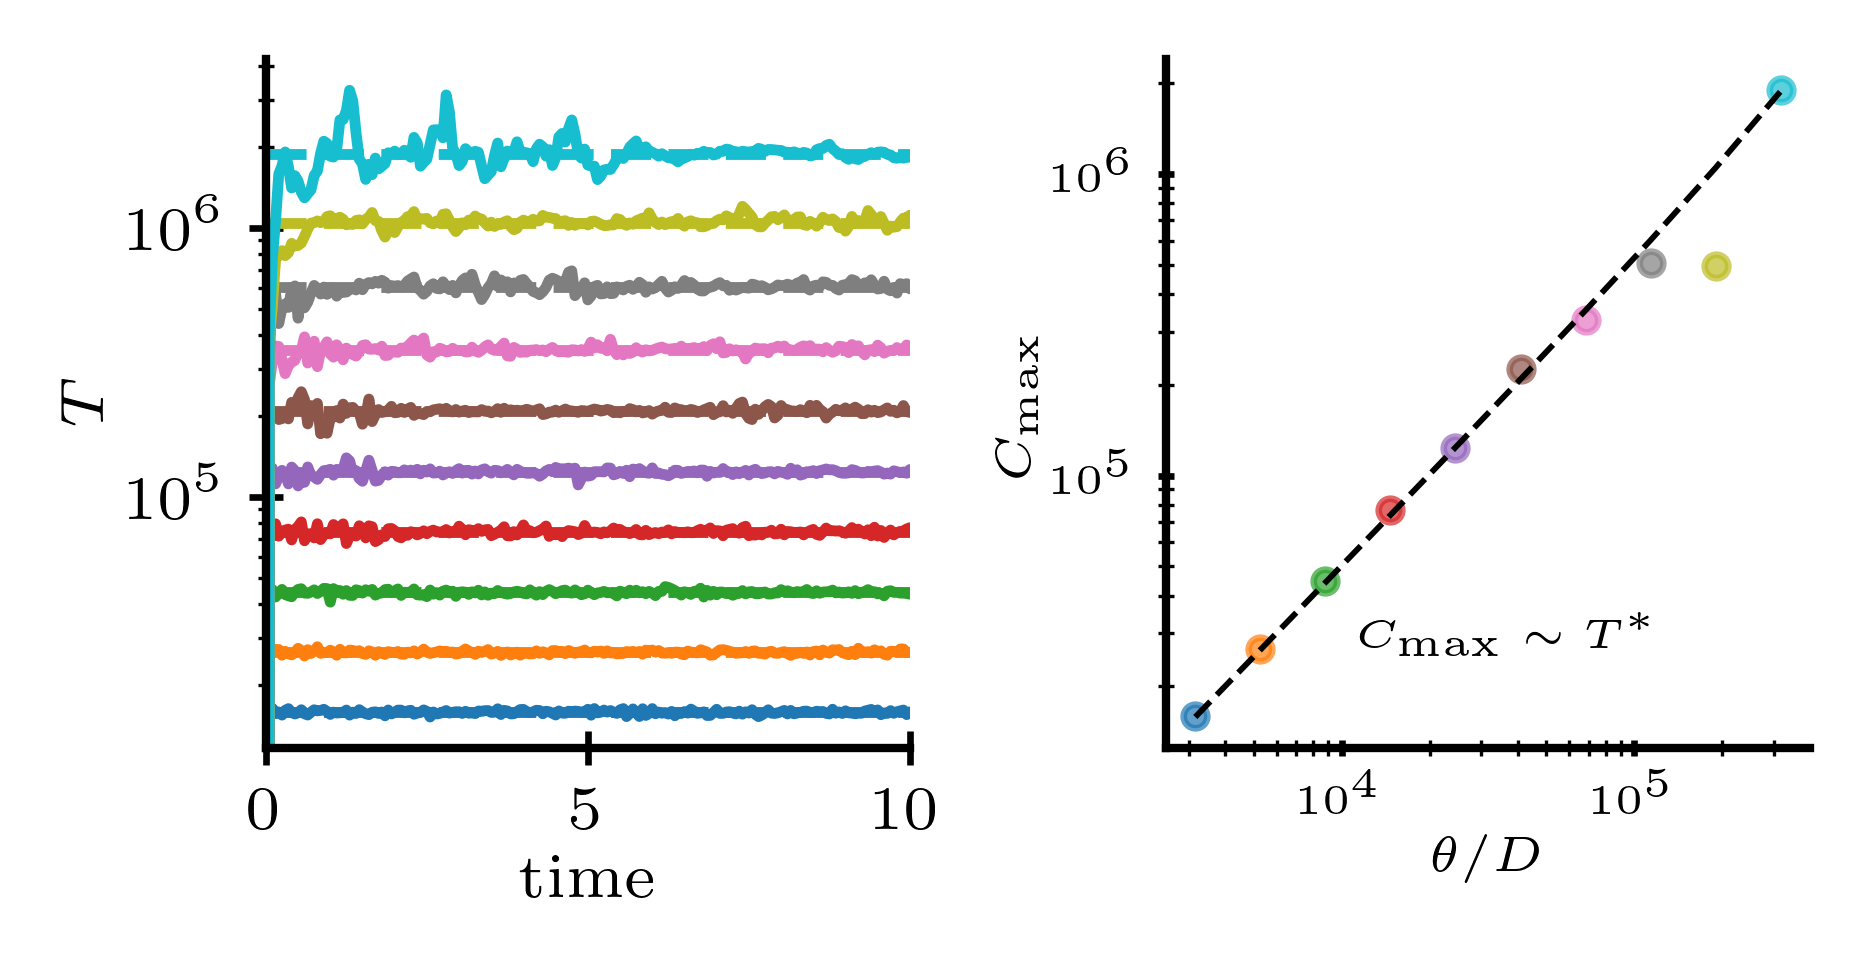

In [517]:
fig, ax = plt.subplots(1, 2, figsize=(3, 1.5), layout='constrained')
D = 1
b = 1e7
T_stars = []
for ratio in ratios:
    line,  = ax[0].plot(results_for_ratio[ratio]['t'], results_for_ratio[ratio]['T'])
    
    d = 0.2 * b / ratio
    theta = D * ratio
    
    T_star = b / (d - D)    
    ax[0].axhline(T_star, c=line.get_color(), linestyle='--')
    ax[1].scatter(ratio, cmaxes_for_ratio[ratio], s=8, alpha=0.7)
    
    T_stars.append(T_star)
    
ax[0].set_yscale('log')
ax[0].set_xlim(0, 10)
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$T$')
 
ax[1].plot(ratios, T_stars , linestyle='--', c='black', lw=0.7)
ax[1].set_xlabel(r'$\theta / D$', fontsize=6)
ax[1].set_ylabel(r'$C_{\max}$', fontsize=6)
ax[1].text(0.3, 0.2, r'$C_{\mathrm{max}} \sim T^{*}$', transform=ax[1].transAxes, fontsize=5, ha='left',va='top')
ax[1].tick_params(axis='both', labelsize=5, length=2)
ax[1].set_xscale('log')
ax[1].set_yscale('log');